#Network anomaly detection
Para detectar anomalías que indiquen tráfico sospechoso o malicioso

Usaremos `Random forest` Para detectar anomalías. Se basa en construir árboles de decisión para separar datos. Las anomalias son los que quedan excluido de todos los otros grupos.

Vamos a usar el dataset NSL-KDD: [NSL-KDD](https://academy.hackthebox.com/storage/modules/292/KDD_dataset.zip)

In [ ]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level'
]


In [ ]:
import pandas as pd
df = pd.read_csv("KDD+.txt", names=columns)

In [ ]:
print(df.head())
print("-"*50)
print(df.info())
print("-"*50)
print(df.shape)

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

# Transformación
Primero vamos a cambiar el target para que sea una clasificación binaria

In [ ]:
df['attack_flag'] = df['attack'].apply(lambda a: 0 if a == 'normal' else 1)
df['attack_flag'].value_counts()

,count
attack_flag,
0,77054
1,71463


In [ ]:
# clasifiación de los ataques en columna attack

dos_attacks = ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod',
               'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm']
probe_attacks = ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']
privilege_attacks = ['buffer_overflow', 'loadmdoule', 'perl', 'ps',
                     'rootkit', 'sqlattack', 'xterm']
access_attacks = ['ftp_write', 'guess_passwd', 'http_tunnel', 'imap',
                  'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack',
                  'snmpguess', 'spy', 'warezclient', 'warezmaster',
                  'xclock', 'xsnoop']

In [ ]:
def map_attack(attack):
    if attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    elif attack in privilege_attacks:
        return 3
    elif attack in access_attacks:
        return 4
    else:
        return 0

In [ ]:
df['attack_map'] = df['attack'].apply(map_attack)
df['attack_map'].value_counts()

,count
attack_map,
0,77207
1,53387
2,14077
4,3738
3,108


In [ ]:
# Para variables categóricas usamos dummies
encoded = pd.get_dummies(df[['protocol_type', 'service']])


In [ ]:
#para variables numéricas unirlas con las de clasificación
numeric_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]

train_set = encoded.join(df[numeric_features])

In [ ]:
# a clasificar
multi_y = df['attack_map']

In [ ]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

In [ ]:
#sacamos una parte de entrenamiento para validar
multi_train_X, multi_val_X, multi_train_y, multi_val_y = train_test_split(train_X, train_y, test_size=0.3, random_state=1337)

#Entrenamiento

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
model = RandomForestClassifier(random_state=110)

In [ ]:
model.fit(multi_train_X, multi_train_y)

RandomForestClassifier(random_state=110)

#Evaluación

In [ ]:
validate_result = model.predict(multi_val_X)

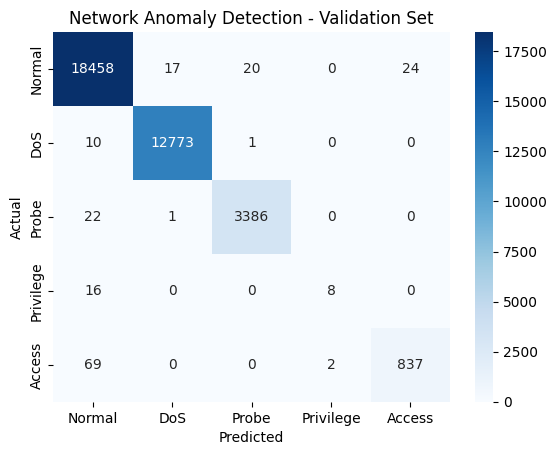

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(multi_val_y, validate_result)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



In [ ]:
from sklearn.metrics import classification_report
print(classification_report(multi_val_y, validate_result, target_names=class_labels))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     18519
         DoS       1.00      1.00      1.00     12784
       Probe       0.99      0.99      0.99      3409
   Privilege       0.80      0.33      0.47        24
      Access       0.97      0.92      0.95       908

    accuracy                           0.99     35644
   macro avg       0.95      0.85      0.88     35644
weighted avg       0.99      0.99      0.99     35644



#Test

In [ ]:
test_predictions = model.predict(test_X)

In [ ]:
print(classification_report(test_y, test_predictions, target_names=class_labels))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     15402
         DoS       1.00      1.00      1.00     10721
       Probe       0.99      1.00      1.00      2796
   Privilege       1.00      0.19      0.32        21
      Access       0.96      0.92      0.94       764

    accuracy                           0.99     29704
   macro avg       0.99      0.82      0.85     29704
weighted avg       0.99      0.99      0.99     29704



#Save

In [ ]:
import joblib
joblib.dump(model, "network_anomaly_detection_model.joblib")

['network_anomaly_detection_model.joblib']